In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
from sklearn.model_selection import KFold
warnings.filterwarnings('ignore')

In [54]:
modeling_data = pd.read_csv('../data/final_youtube_v3.csv')
modeling_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17528 non-null  int64  
 1   views                     17528 non-null  int64  
 2   likes                     17528 non-null  int64  
 3   comments                  17528 non-null  int64  
 4   views_log                 17528 non-null  float64
 5   likes_log                 17528 non-null  float64
 6   comments_log              17528 non-null  float64
 7   likes_log_win             17528 non-null  float64
 8   comments_log_win          17528 non-null  float64
 9   views_log_win             17528 non-null  float64
 10  duration_scaled           17528 non-null  float64
 11  framerate_scaled          17528 non-null  float64
 12  bitrate_scaled            17528 non-null  float64
 13  views_log_scaled          17528 non-null  float64
 14  likes_

In [55]:
cat_columns = [col for col in modeling_data.columns if col.startswith('cat_')]

for col in cat_columns:
    modeling_data[col] = modeling_data[col].astype(int)

print(f"✅ Converted {len(cat_columns)} category columns to int")

print(f"\nData types:")
print(modeling_data[cat_columns].dtypes.value_counts())

✅ Converted 15 category columns to int

Data types:
int64    15
Name: count, dtype: int64


In [56]:
modeling_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                17528 non-null  int64  
 1   views                     17528 non-null  int64  
 2   likes                     17528 non-null  int64  
 3   comments                  17528 non-null  int64  
 4   views_log                 17528 non-null  float64
 5   likes_log                 17528 non-null  float64
 6   comments_log              17528 non-null  float64
 7   likes_log_win             17528 non-null  float64
 8   comments_log_win          17528 non-null  float64
 9   views_log_win             17528 non-null  float64
 10  duration_scaled           17528 non-null  float64
 11  framerate_scaled          17528 non-null  float64
 12  bitrate_scaled            17528 non-null  float64
 13  views_log_scaled          17528 non-null  float64
 14  likes_

# Loại bỏ các cột có thể dẫn đến data leakage

In [57]:
leakage_features = [
    'views', 'comments',
    'likes_log_win',

    'likes_log_scaled',
    'likes_log_win_scaled',

    'Unnamed: 0',

]

# Loại bỏ các cột tồn tại
existing_leakage = [col for col in leakage_features if col in modeling_data.columns]
df_clean = modeling_data.drop(columns=existing_leakage, errors='ignore')

print(f"Removed {len(existing_leakage)} leakage features")
print(f"Remaining: {df_clean.shape[1]} columns")

Removed 6 leakage features
Remaining: 45 columns


In [58]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17528 entries, 0 to 17527
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   likes                     17528 non-null  int64  
 1   views_log                 17528 non-null  float64
 2   likes_log                 17528 non-null  float64
 3   comments_log              17528 non-null  float64
 4   comments_log_win          17528 non-null  float64
 5   views_log_win             17528 non-null  float64
 6   duration_scaled           17528 non-null  float64
 7   framerate_scaled          17528 non-null  float64
 8   bitrate_scaled            17528 non-null  float64
 9   views_log_scaled          17528 non-null  float64
 10  comments_log_scaled       17528 non-null  float64
 11  comments_log_win_scaled   17528 non-null  float64
 12  views_log_win_scaled      17528 non-null  float64
 13  has_description           17528 non-null  int64  
 14  has_ha

# Chuẩn bị data cho huấn luyện

In [59]:
# Target
y = df_clean['likes_log']

# Features
X = df_clean.drop(columns=['likes_log', 'likes'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print(f"Split ratio: 80/20")

X shape: (17528, 43)
y shape: (17528,)
Train set: (14022, 43)
Test set:  (3506, 43)
Split ratio: 80/20


# Tạo pipeline huấn luyện

In [60]:
pipeline = Pipeline([
    ("poly", PolynomialFeatures(
        degree=1,
        interaction_only=True,
        include_bias=False
    )),
    ("ridge", Ridge())
])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)


In [61]:
y_train_pred_log = pipeline.predict(X_train)
y_test_pred_log = pipeline.predict(X_test)

y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

# Đánh giá trên tập kiểm thử và huấn luyện

In [62]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.8096          0.8151
MSE                           0.4659          0.4735
RMSE                          0.6826          0.6881
MAE                           0.5158          0.5220

Overfit (R² diff)            -0.0055
   ✅ Model generalize tốt


# Plot đánh giá

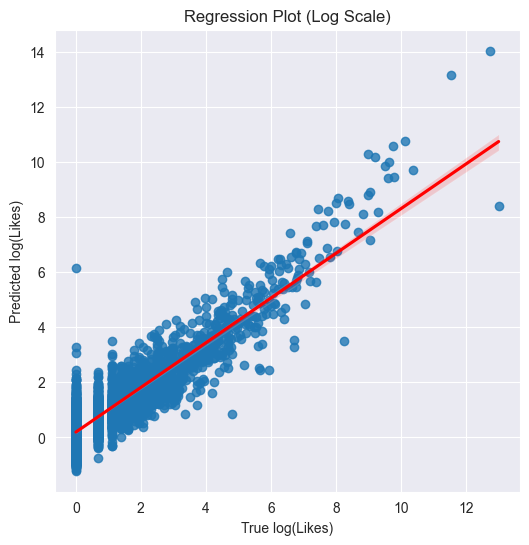

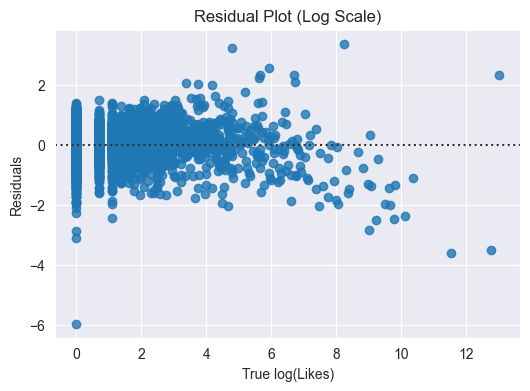

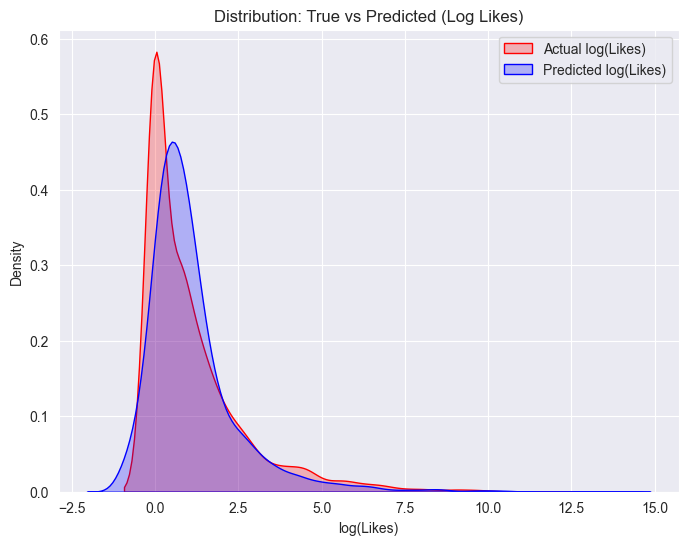

In [63]:
y_true = y_test
y_pred = y_pred
residuals = y_true - y_pred

# ----- Regression plot (log scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

# ----- Residual plot (log scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

# ----- Distribution comparison -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [64]:
k = 5
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mse_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mae_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')

In [65]:
mse_scores = pd.DataFrame(mse_scores*-1, columns=['MSE'])
rmse_scores = pd.DataFrame(rmse_scores*-1, columns=['RMSE'])
mae_scores = pd.DataFrame(mae_scores*-1, columns=['MAE'])
r2_scores = pd.DataFrame(r2_scores, columns=['R2'])
score = pd.concat([mse_scores, rmse_scores, mae_scores, r2_scores], axis=1)
score

,MSE,RMSE,MAE,R2
0,0.453320,0.673290,0.509859,0.818201
1,0.435202,0.659698,0.506750,0.818813
2,0.493492,0.702490,0.527343,0.808040
3,0.474196,0.688619,0.523279,0.814754
4,0.491897,0.701354,0.523713,0.788327


In [66]:
print(f"Average MSE across {k} folds: {np.mean(mse_scores):.2f}")
print(f"Average RMSE across {k} folds: {np.mean(rmse_scores):.2f}")
print(f"Average MAE across {k} folds: {np.mean(mae_scores):.2f}")
print(f"Average R2 across {k} folds: {np.mean(r2_scores):.2f}")

Average MSE across 5 folds: 0.47
Average RMSE across 5 folds: 0.69
Average MAE across 5 folds: 0.52
Average R2 across 5 folds: 0.81


EVALUATION ON ORIGINAL LIKES SCALE
Metric                              Train                 Test
----------------------------------------------------------------------
R² Score                          -0.4609              -2.4962
MSE                         96,885,483.66       333,064,252.51
RMSE                             9,843.04            18,250.05
MAE                                195.96               555.50

Overfit (R² diff)                  2.0353
   ⚠️ Model có dấu hiệu overfit


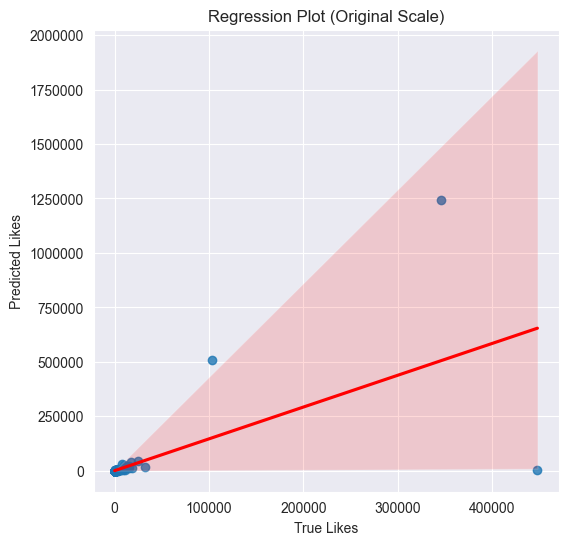

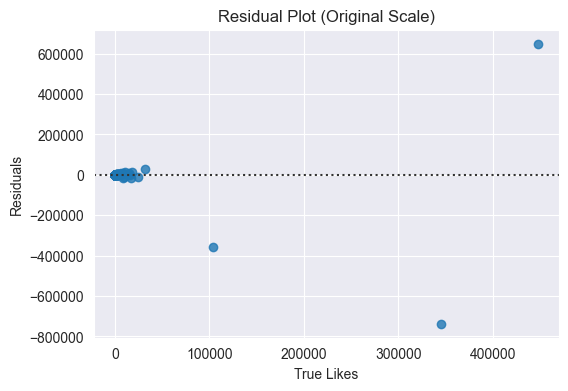

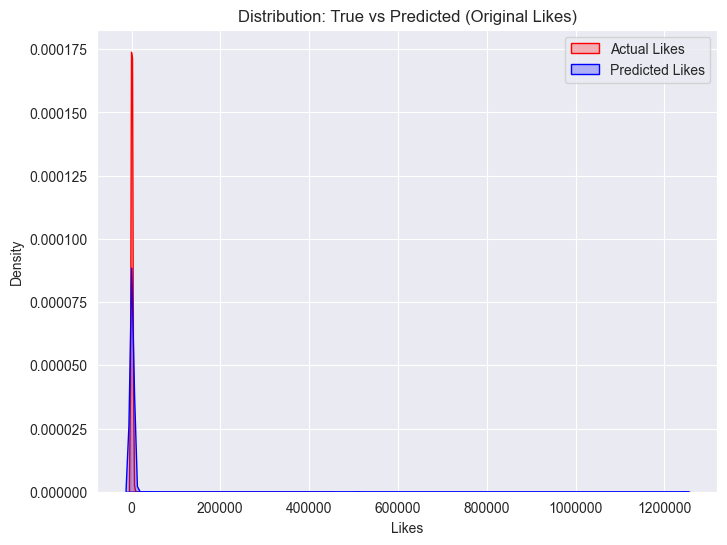

In [67]:
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

r2_train_orig = r2_score(y_train_orig, y_train_pred_orig)
r2_test_orig = r2_score(y_test_orig, y_test_pred_orig)
mse_train_orig = mean_squared_error(y_train_orig, y_train_pred_orig)
mse_test_orig = mean_squared_error(y_test_orig, y_test_pred_orig)
mae_train_orig = mean_absolute_error(y_train_orig, y_train_pred_orig)
mae_test_orig = mean_absolute_error(y_test_orig, y_test_pred_orig)

print(f"{'='*70}")
print(f"EVALUATION ON ORIGINAL LIKES SCALE")
print(f"{'='*70}")
print(f"{'Metric':<20s} {'Train':>20s} {'Test':>20s}")
print("-" * 70)
print(f"{'R² Score':<20s} {r2_train_orig:>20.4f} {r2_test_orig:>20.4f}")
print(f"{'MSE':<20s} {mse_train_orig:>20,.2f} {mse_test_orig:>20,.2f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_orig):>20,.2f} {np.sqrt(mse_test_orig):>20,.2f}")
print(f"{'MAE':<20s} {mae_train_orig:>20,.2f} {mae_test_orig:>20,.2f}")

overfit = r2_train_orig - r2_test_orig
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>20.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

y_true_orig = y_test_orig
y_pred_orig = y_test_pred_orig
residuals_orig = y_true_orig - y_pred_orig

# ----- 1. Regression plot (Original Scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true_orig, y=y_pred_orig, line_kws={'color':'red'})
plt.xlabel("True Likes")
plt.ylabel("Predicted Likes")
plt.title("Regression Plot (Original Scale)")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

# ----- 2. Residual plot (Original Scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true_orig, y=residuals_orig, line_kws={'color':'red'})
plt.xlabel("True Likes")
plt.ylabel("Residuals")
plt.title("Residual Plot (Original Scale)")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

# ----- 3. Distribution comparison (Original Scale) -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true_orig, color='red', label='Actual Likes', shade=True)
sns.kdeplot(y_pred_orig, color='blue', label='Predicted Likes', shade=True)
plt.title('Distribution: True vs Predicted (Original Likes)')
plt.xlabel('Likes')
plt.ylabel('Density')
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.show()

# Thực nghiệm với poly_degree = 2

In [68]:
pipeline2 = Pipeline([
    ("poly", PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    )),
    ("ridge", Ridge())
])

# Fit
pipeline2.fit(X_train, y_train)

# Predict
y_pred = pipeline2.predict(X_test)


In [69]:
y_train_pred_log = pipeline2.predict(X_train)
y_test_pred_log = pipeline2.predict(X_test)

y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

In [70]:
r2_train_log = r2_score(y_train, y_train_pred_log)
r2_test_log = r2_score(y_test, y_test_pred_log)
mse_train_log = mean_squared_error(y_train, y_train_pred_log)
mse_test_log = mean_squared_error(y_test, y_test_pred_log)
mae_train_log = mean_absolute_error(y_train, y_train_pred_log)
mae_test_log = mean_absolute_error(y_test, y_test_pred_log)

print(f"{'Metric':<20s} {'Train':>15s} {'Test':>15s}")
print("-" * 60)
print(f"{'R² Score':<20s} {r2_train_log:>15.4f} {r2_test_log:>15.4f}")
print(f"{'MSE':<20s} {mse_train_log:>15.4f} {mse_test_log:>15.4f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_log):>15.4f} {np.sqrt(mse_test_log):>15.4f}")
print(f"{'MAE':<20s} {mae_train_log:>15.4f} {mae_test_log:>15.4f}")

overfit = r2_train_log - r2_test_log
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>15.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

Metric                         Train            Test
------------------------------------------------------------
R² Score                      0.8536          0.8212
MSE                           0.3583          0.4579
RMSE                          0.5986          0.6767
MAE                           0.4396          0.4549

Overfit (R² diff)             0.0324
   ✅ Model generalize tốt


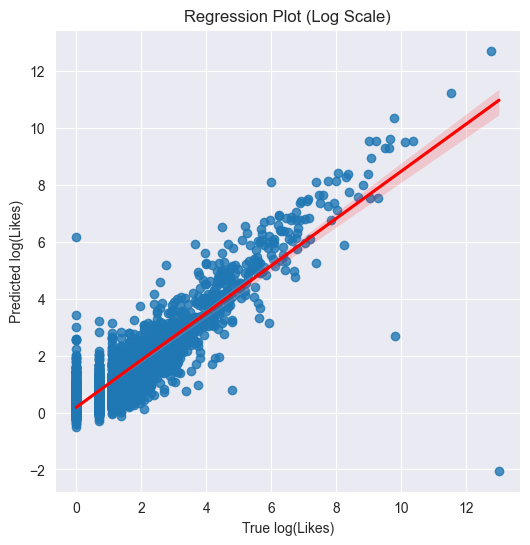

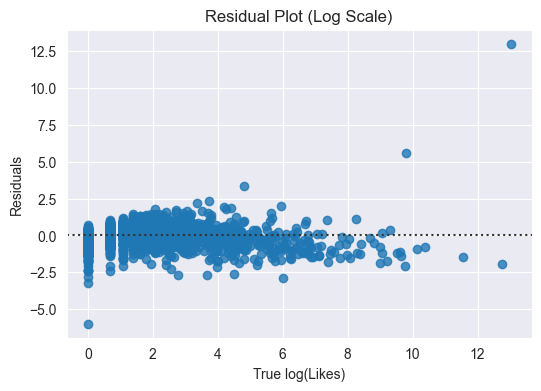

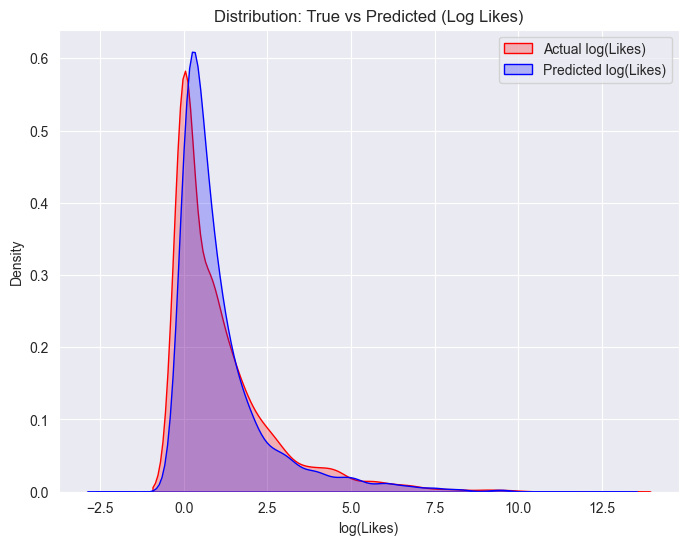

In [71]:
y_true = y_test
y_pred = y_pred
residuals = y_true - y_pred

# ----- Regression plot (log scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true, y=y_pred, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Predicted log(Likes)")
plt.title("Regression Plot (Log Scale)")
plt.show()

# ----- Residual plot (log scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true, y=residuals, line_kws={'color':'red'})
plt.xlabel("True log(Likes)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Log Scale)")
plt.show()

# ----- Distribution comparison -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true, color='red', label='Actual log(Likes)', shade=True)
sns.kdeplot(y_pred, color='blue', label='Predicted log(Likes)', shade=True)
plt.title('Distribution: True vs Predicted (Log Likes)')
plt.xlabel('log(Likes)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [72]:
k = 5
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mse_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='neg_mean_squared_error')
rmse_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='neg_root_mean_squared_error')
mae_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(pipeline2, X, y, cv=kf, scoring='r2')

In [73]:
mse_scores = pd.DataFrame(mse_scores*-1, columns=['MSE'])
rmse_scores = pd.DataFrame(rmse_scores*-1, columns=['RMSE'])
mae_scores = pd.DataFrame(mae_scores*-1, columns=['MAE'])
r2_scores = pd.DataFrame(r2_scores, columns=['R2'])
score = pd.concat([mse_scores, rmse_scores, mae_scores, r2_scores], axis=1)
score

,MSE,RMSE,MAE,R2
0,0.354405,0.595319,0.439557,0.857870
1,0.366717,0.605571,0.450205,0.847326
2,0.435234,0.659723,0.460850,0.830701
3,0.388245,0.623093,0.455461,0.848331
4,0.421996,0.649612,0.463209,0.818407


In [74]:
print(f"Average MSE across {k} folds: {np.mean(mse_scores):.2f}")
print(f"Average RMSE across {k} folds: {np.mean(rmse_scores):.2f}")
print(f"Average MAE across {k} folds: {np.mean(mae_scores):.2f}")
print(f"Average R2 across {k} folds: {np.mean(r2_scores):.2f}")

Average MSE across 5 folds: 0.39
Average RMSE across 5 folds: 0.63
Average MAE across 5 folds: 0.45
Average R2 across 5 folds: 0.84


In [75]:
def analyze_feature_importance(model, X, top_n=20):

    # Extract feature names after PolynomialFeatures
    poly = model.named_steps['poly']
    ridge = model.named_steps['ridge']

    feature_names = poly.get_feature_names_out(X.columns)

    # Extract coefficients
    coef = ridge.coef_

    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef,
        'Abs_Coefficient': np.abs(coef)
    }).sort_values('Abs_Coefficient', ascending=False)

    # Print top features
    print(f"\n{'='*80}")
    print(f"TOP {top_n} MOST IMPORTANT FEATURES (by |Coefficient|)")
    print(f"{'='*80}")
    print(feature_importance.head(top_n).to_string(index=False))

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    top_positive = feature_importance.sort_values(
        'Coefficient', ascending=False
    ).head(top_n)

    axes[0].barh(
        top_positive['Feature'][::-1],
        top_positive['Coefficient'][::-1],
        alpha=0.7
    )
    axes[0].set_title(f'Top {top_n} Positive Effects')
    axes[0].set_xlabel('Coefficient Value')

    top_negative = feature_importance.sort_values(
        'Coefficient', ascending=True
    ).head(top_n)

    axes[1].barh(
        top_negative['Feature'][::-1],
        top_negative['Coefficient'][::-1],
        alpha=0.7
    )
    axes[1].set_title(f'Top {top_n} Negative Effects')
    axes[1].set_xlabel('Coefficient Value')

    plt.tight_layout()
    plt.show()

    return feature_importance


TOP 20 MOST IMPORTANT FEATURES (by |Coefficient|)
                Feature  Coefficient  Abs_Coefficient
resolution_score_scaled     1.339634         1.339634
                  is_4k    -0.362750         0.362750
       views_log_scaled     0.340209         0.340209
              views_log     0.340209         0.340209
           comments_log     0.331007         0.331007
    comments_log_scaled     0.331007         0.331007
              cat_Shows     0.328183         0.328183
          views_log_win    -0.186058         0.186058
   views_log_win_scaled    -0.186058         0.186058
   cat_Film & Animation     0.157637         0.157637
           aspect_ratio     0.153782         0.153782
     cat_People & Blogs     0.119650         0.119650
              cat_Music     0.108284         0.108284
            is_high_fps     0.101171         0.101171
         bitrate_scaled    -0.098159         0.098159
    is_popular_category     0.093435         0.093435
             is_full_hd     0.0

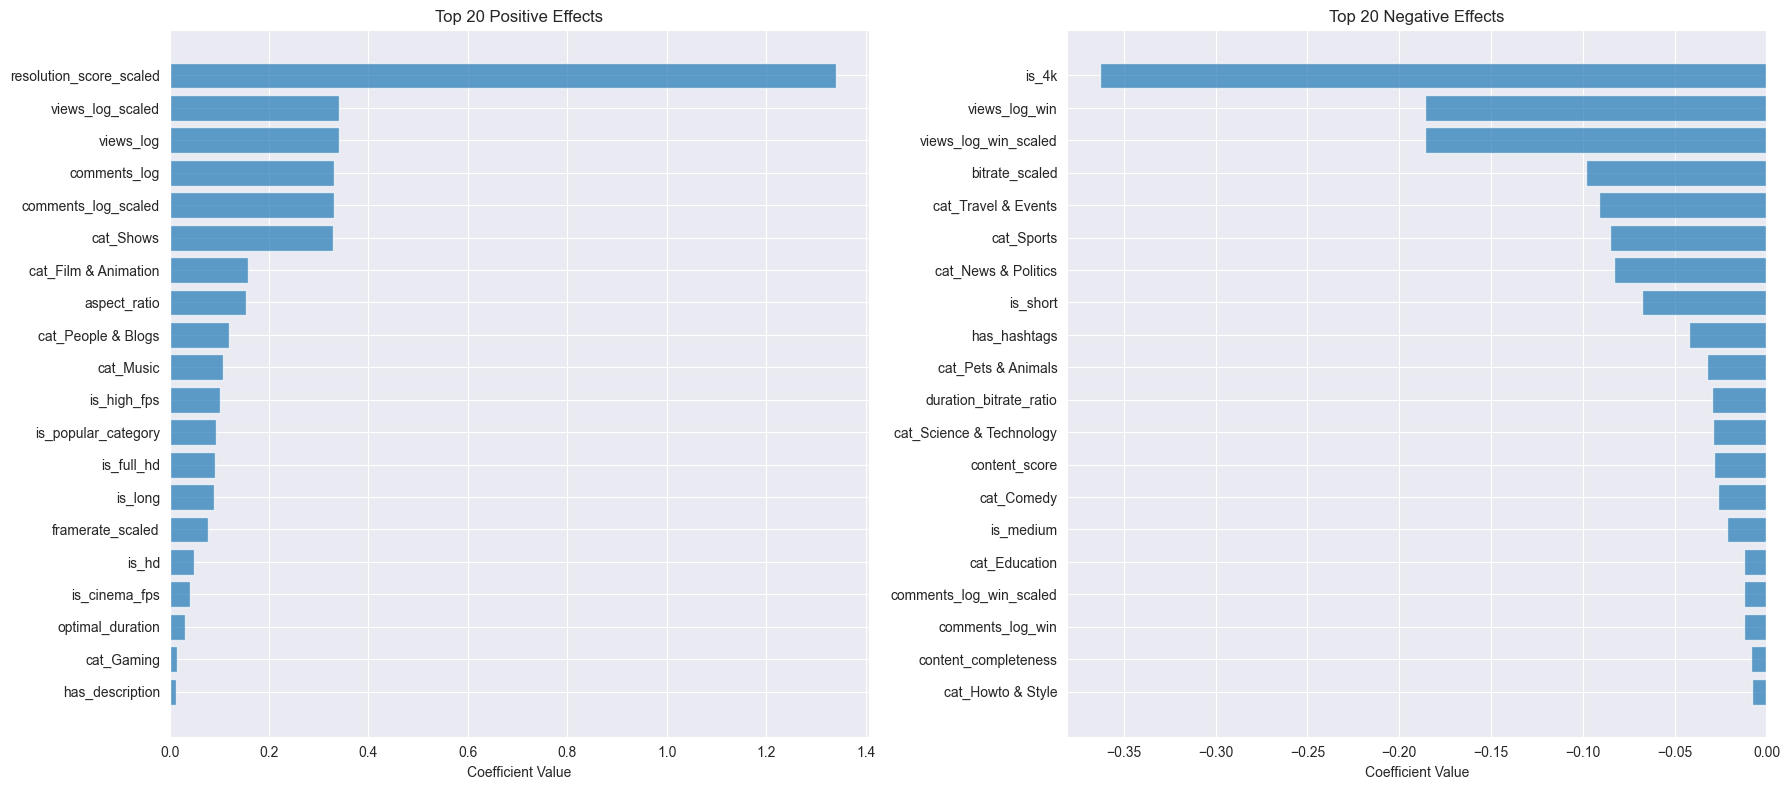

In [76]:
feature_importance = analyze_feature_importance(
    pipeline,
    X_train,
    top_n=20
)


TOP 20 MOST IMPORTANT FEATURES (by |Coefficient|)
                                      Feature  Coefficient  Abs_Coefficient
                  views_log_win cat_Education     0.867187         0.867187
           views_log_win_scaled cat_Education     0.867187         0.867187
               views_log_scaled cat_Education    -0.858116         0.858116
                      views_log cat_Education    -0.858116         0.858116
                         cat_Shows is_full_hd     0.717495         0.717495
            cat_Music resolution_score_scaled     0.565822         0.565822
               is_long duration_bitrate_ratio    -0.534425         0.534425
  resolution_score_scaled is_popular_category     0.462616         0.462616
         resolution_score_scaled aspect_ratio    -0.457234         0.457234
              resolution_score_scaled is_long    -0.398343         0.398343
 cat_Film & Animation resolution_score_scaled     0.395956         0.395956
 views_log_win_scaled resolution_scor

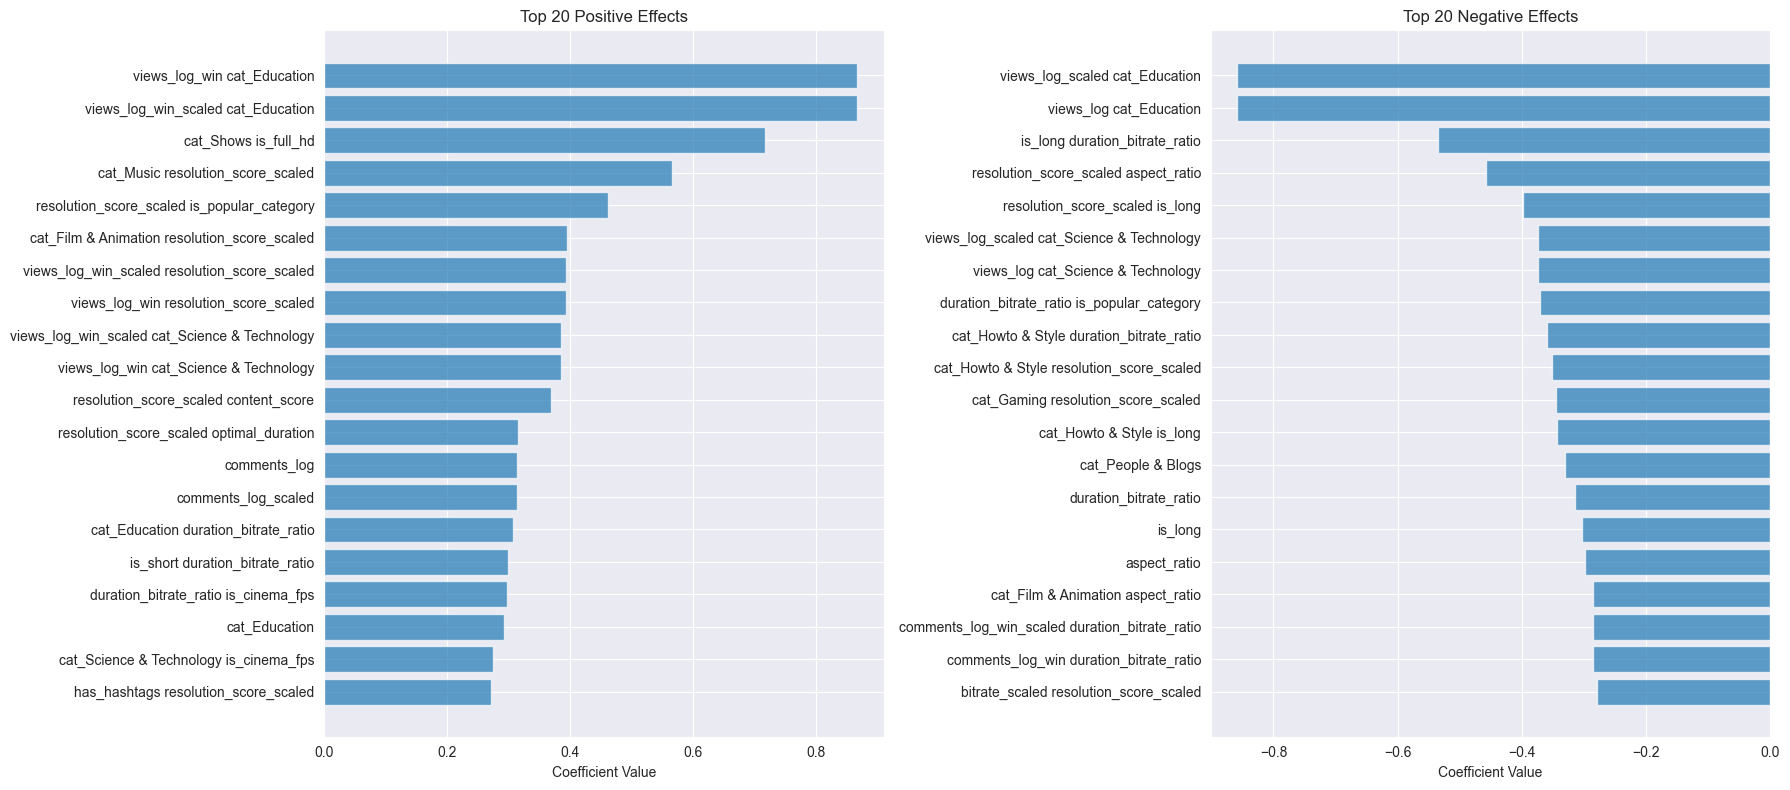

In [77]:
feature_importance_poly2 = analyze_feature_importance(
    pipeline2,
    X_train,
    top_n=20
)

EVALUATION ON ORIGINAL LIKES SCALE
Metric                              Train                 Test
----------------------------------------------------------------------
R² Score                           0.9317               0.3924
MSE                          4,532,609.54        57,883,442.15
RMSE                             2,128.99             7,608.12
MAE                                 67.75               187.13

Overfit (R² diff)                  0.5393
   ⚠️ Model có dấu hiệu overfit


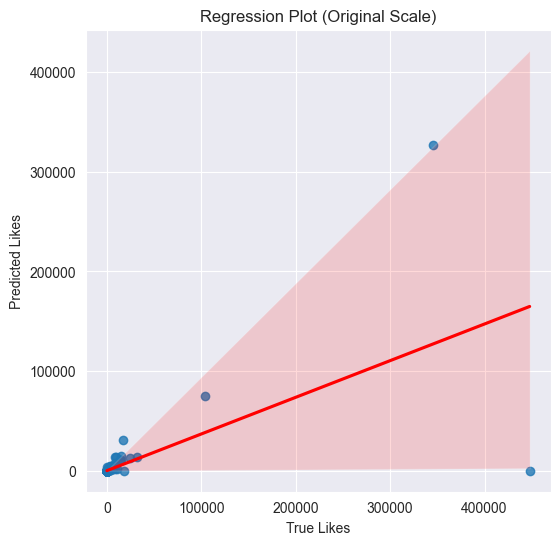

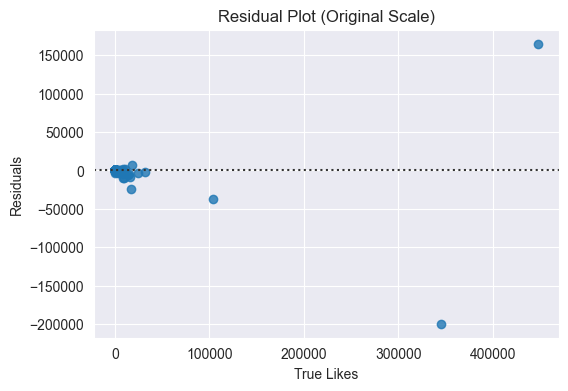

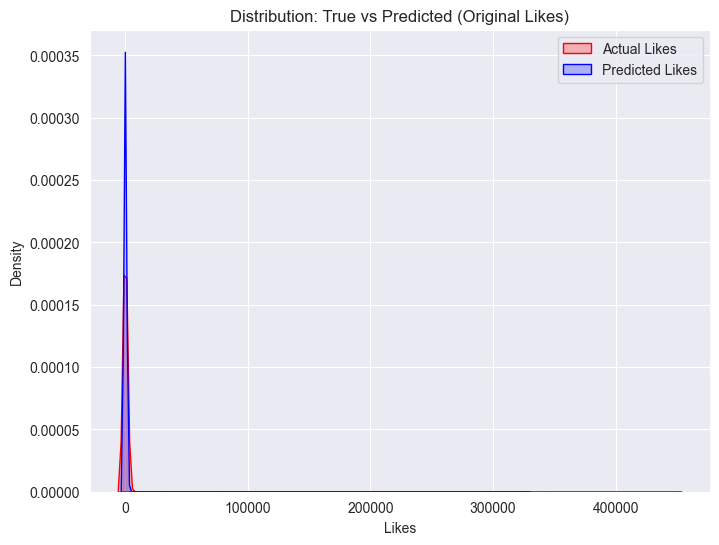

In [78]:
y_train_orig = np.expm1(y_train)
y_test_orig = np.expm1(y_test)
y_train_pred_orig = np.expm1(y_train_pred_log)
y_test_pred_orig = np.expm1(y_test_pred_log)

r2_train_orig = r2_score(y_train_orig, y_train_pred_orig)
r2_test_orig = r2_score(y_test_orig, y_test_pred_orig)
mse_train_orig = mean_squared_error(y_train_orig, y_train_pred_orig)
mse_test_orig = mean_squared_error(y_test_orig, y_test_pred_orig)
mae_train_orig = mean_absolute_error(y_train_orig, y_train_pred_orig)
mae_test_orig = mean_absolute_error(y_test_orig, y_test_pred_orig)

print(f"{'='*70}")
print(f"EVALUATION ON ORIGINAL LIKES SCALE")
print(f"{'='*70}")
print(f"{'Metric':<20s} {'Train':>20s} {'Test':>20s}")
print("-" * 70)
print(f"{'R² Score':<20s} {r2_train_orig:>20.4f} {r2_test_orig:>20.4f}")
print(f"{'MSE':<20s} {mse_train_orig:>20,.2f} {mse_test_orig:>20,.2f}")
print(f"{'RMSE':<20s} {np.sqrt(mse_train_orig):>20,.2f} {np.sqrt(mse_test_orig):>20,.2f}")
print(f"{'MAE':<20s} {mae_train_orig:>20,.2f} {mae_test_orig:>20,.2f}")

overfit = r2_train_orig - r2_test_orig
print(f"\n{'Overfit (R² diff)':<20s} {overfit:>20.4f}")

if overfit > 0.1:
    print(f"   ⚠️ Model có dấu hiệu overfit")
elif overfit < -0.1:
    print(f"   ⚠️ Model có dấu hiệu underfit")
else:
    print(f"   ✅ Model generalize tốt")

y_true_orig = y_test_orig
y_pred_orig = y_test_pred_orig
residuals_orig = y_true_orig - y_pred_orig

# ----- 1. Regression plot (Original Scale) -----
plt.figure(figsize=(6,6))
sns.regplot(x=y_true_orig, y=y_pred_orig, line_kws={'color':'red'})
plt.xlabel("True Likes")
plt.ylabel("Predicted Likes")
plt.title("Regression Plot (Original Scale)")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

# ----- 2. Residual plot (Original Scale) -----
plt.figure(figsize=(6,4))
sns.residplot(x=y_true_orig, y=residuals_orig, line_kws={'color':'red'})
plt.xlabel("True Likes")
plt.ylabel("Residuals")
plt.title("Residual Plot (Original Scale)")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

# ----- 3. Distribution comparison (Original Scale) -----
plt.figure(figsize=(8,6))
sns.kdeplot(y_true_orig, color='red', label='Actual Likes', shade=True)
sns.kdeplot(y_pred_orig, color='blue', label='Predicted Likes', shade=True)
plt.title('Distribution: True vs Predicted (Original Likes)')
plt.xlabel('Likes')
plt.ylabel('Density')
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.show()